# LECCIÓN 2 - PRUEBAS DE NORMALIDAD

## 1. El set de datos

In [1]:
import pandas as pd

df = pd.read_csv('distribuciones.csv')
df

,normal,cuasi_normal,sesgo_derecha,sesgo_izquierda,bimodal
0,0.496714,0.581265,2.066372,0.265392,-0.360999
1,-0.138264,0.586960,0.733192,-0.027286,-2.298126
2,0.647689,-0.488916,0.334147,-0.971504,-1.321441
3,1.523030,0.685852,1.832819,0.029322,-2.122587
4,-0.234153,-0.757140,-0.295116,-0.728540,-2.734416
...,...,...,...,...,...
995,-0.281100,0.843966,-0.003483,-0.307898,2.174890
996,1.797687,-0.153759,1.334224,-0.532479,3.214705
997,0.640843,1.487833,-1.460228,-0.720398,3.700865
998,-0.571179,-0.104132,1.815591,-0.392191,2.858692


## 2. Histogramas

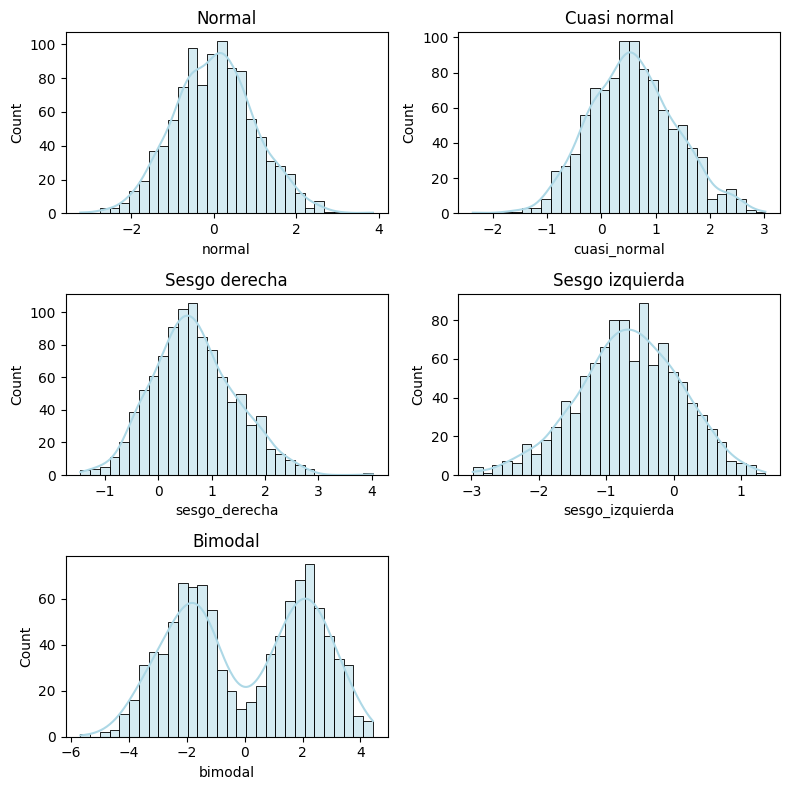

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for i, column in enumerate(df.columns, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[column], kde=True, bins=30, color='lightblue') # Kernel density estimation
    plt.title(column.replace("_", " ").capitalize())
plt.tight_layout()

## 3. Gráficos Q-Q

In [ ]:
# !pip install statsmodels

/Users/miguel/.pyenv/versions/3.11.2/envs/academy/lib/python3.11/site-packages/statsmodels/graphics/gofplots.py:1043: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


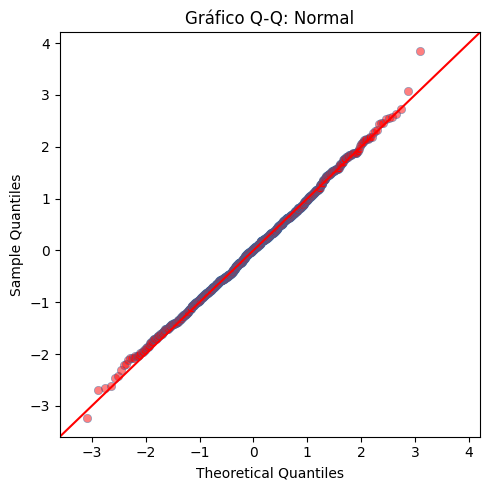

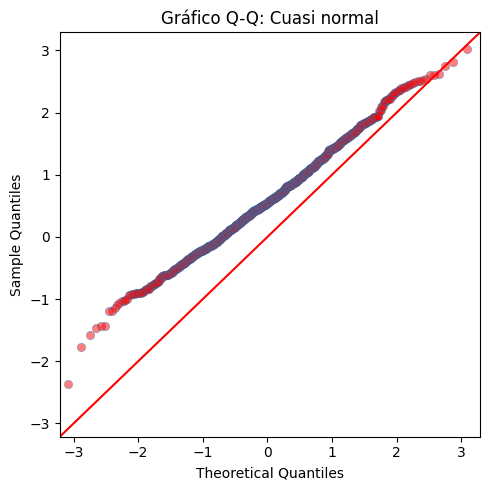

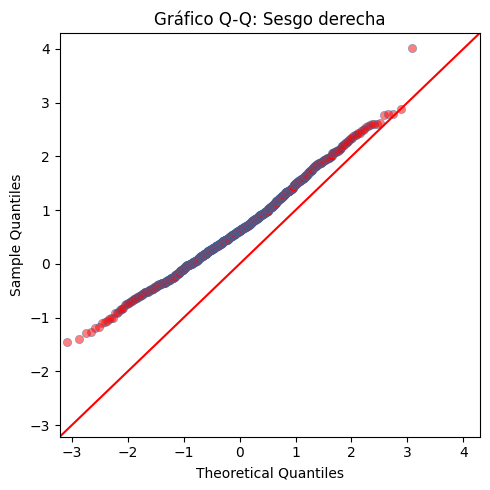

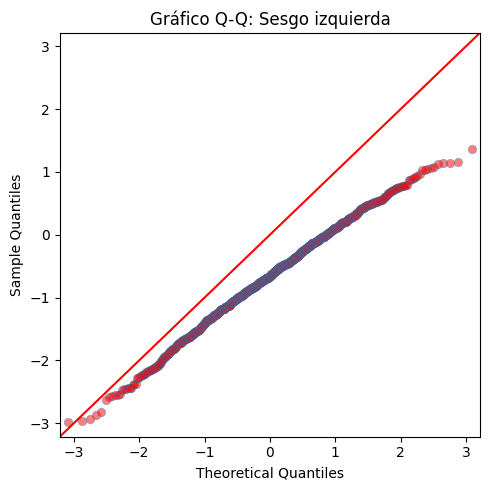

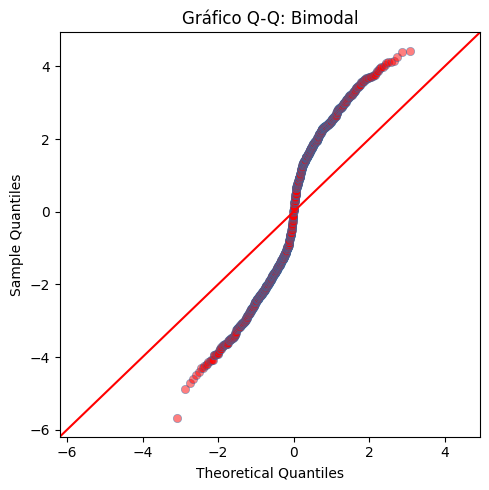

In [ ]:
# Gráficos básicos con statsmodels
import statsmodels.api as sm

for i, column in enumerate(df.columns, 1):
    fig, ax = plt.subplots(figsize=(5,5))
    sm.qqplot(df[column], line='45', alpha=0.5, lw=1, color='blue', 
              markerfacecolor='red', markeredgewidth=0.5, 
              ax=ax)
    plt.title(f'Gráfico Q-Q: {column.replace("_", " ").capitalize()}')
    plt.tight_layout();

Se sugiere usar intervalos de confianza (IC) del 95%. Interpretación:

> Si los datos realmente provinieran de una distribución normal, entonces aproximadamente el 95% de las muestras generadas de forma aleatoria de ese tamaño tendrían sus puntos (cuantiles) dentro de esa franja gris que rodea la línea diagonal.

In [ ]:
#!pip install pingouin

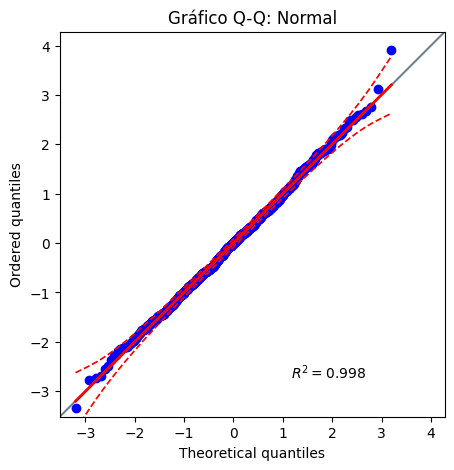

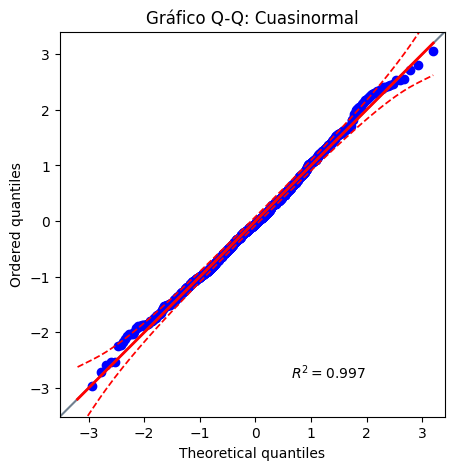

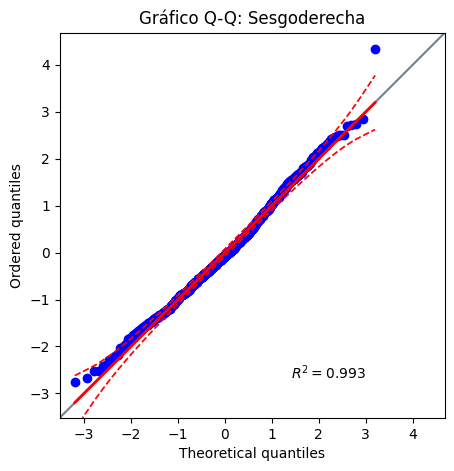

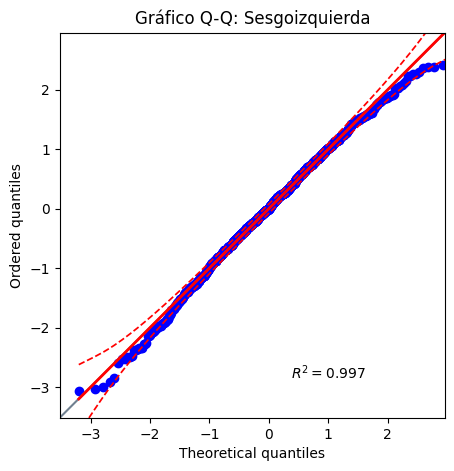

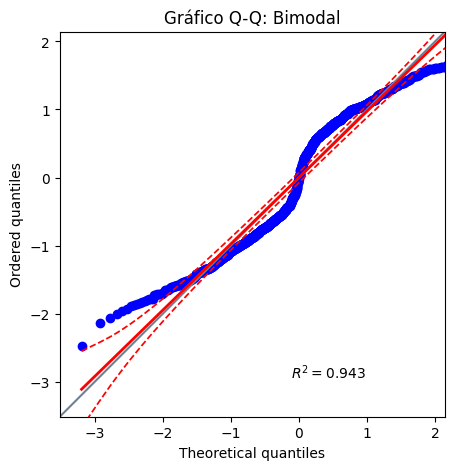

In [4]:
# Gráficos Q-Q con intervalo de confianza del 95%
import pingouin as pg

for column in df.columns:
    fig, ax = plt.subplots(figsize=(5, 5))
    pg.qqplot(df[column], dist='norm', confidence=.95, ax=ax)
    ax.set_title(f"Gráfico Q-Q: {column.replace('_', '').capitalize()}")

## 3. Prueba de Kolmogorov-Smirnov

In [ ]:
# !pip install scipy

In [5]:
from scipy.stats import kstest

# Iterar por cada columna del DataFrame, calcular estadística y valor p e imprimir resultado
for column in df.columns:
    D, p_ks = kstest(df[column], 'norm', args=(0, 1)) # args=(0,1): distribución normal estandarizada

    # Imprimir resultados
    print(f"📊 Prueba Kolmogorov-Smirnov para: {column}")
    print(f"  Estadística (D) = {D:.4f}, p = {p_ks:.10f} {'❌ Rechazar H₀ (p<0.05)' if p_ks < 0.05 else '✅ No se rechaza H₀ (p>=0.05)'}\n")

📊 Prueba Kolmogorov-Smirnov para: normal
  Estadística (D) = 0.0173, p = 0.9196626608 ✅ No se rechaza H₀ (p>=0.05)

📊 Prueba Kolmogorov-Smirnov para: cuasi_normal
  Estadística (D) = 0.2665, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)

📊 Prueba Kolmogorov-Smirnov para: sesgo_derecha
  Estadística (D) = 0.3167, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)

📊 Prueba Kolmogorov-Smirnov para: sesgo_izquierda
  Estadística (D) = 0.3094, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)

📊 Prueba Kolmogorov-Smirnov para: bimodal
  Estadística (D) = 0.3071, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)



## 4. Prueba de Shapiro-Wilk

In [6]:
from scipy.stats import shapiro

# Iterar por cada columna del DataFrame, calcular estadística y valor p e imprimir resultado
for column in df.columns:
    W, p_shapiro = shapiro(df[column])

    # Imprimir resultados
    print(f"📊 Prueba Shapiro-Wilk para: {column}")
    print(f"  Estadística (W) = {W:.4f}, p = {p_shapiro:.10f} {'❌ Rechazar H₀ (p<0.05)' if p_shapiro < 0.05 else '✅ No se rechaza H₀ (p>=0.05)'}\n")

📊 Prueba Shapiro-Wilk para: normal
  Estadística (W) = 0.9986, p = 0.6272578290 ✅ No se rechaza H₀ (p>=0.05)

📊 Prueba Shapiro-Wilk para: cuasi_normal
  Estadística (W) = 0.9968, p = 0.0412223172 ❌ Rechazar H₀ (p<0.05)

📊 Prueba Shapiro-Wilk para: sesgo_derecha
  Estadística (W) = 0.9935, p = 0.0002412940 ❌ Rechazar H₀ (p<0.05)

📊 Prueba Shapiro-Wilk para: sesgo_izquierda
  Estadística (W) = 0.9962, p = 0.0158835142 ❌ Rechazar H₀ (p<0.05)

📊 Prueba Shapiro-Wilk para: bimodal
  Estadística (W) = 0.9418, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)



## 5. Método sugerido: complementar métodos gráficos con pruebas estadísticas

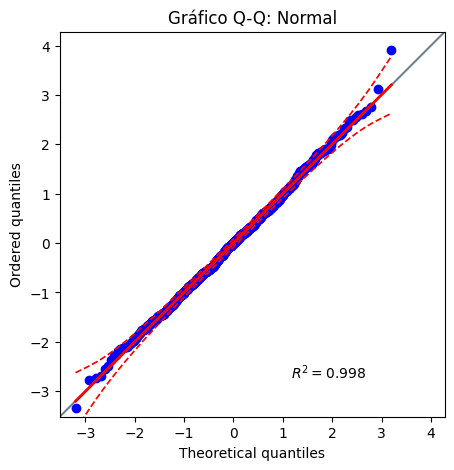

📊 Prueba estadísticas para: normal
  Kolmogorov-Smirnov - Estadística (D) = 0.0173, p = 0.9196626608 ✅ No se rechaza H₀ (p>=0.05)

  Shapiro-Wilk    -    Estadística (W) = 0.9986, p = 0.6272578290 ✅ No se rechaza H₀ (p>=0.05)



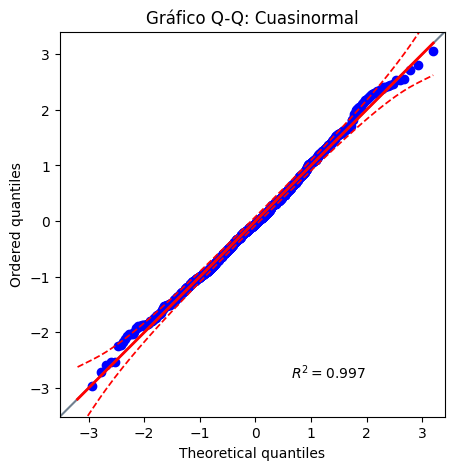

📊 Prueba estadísticas para: cuasi_normal
  Kolmogorov-Smirnov - Estadística (D) = 0.2665, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)

  Shapiro-Wilk    -    Estadística (W) = 0.9968, p = 0.0412223172 ❌ Rechazar H₀ (p<0.05)



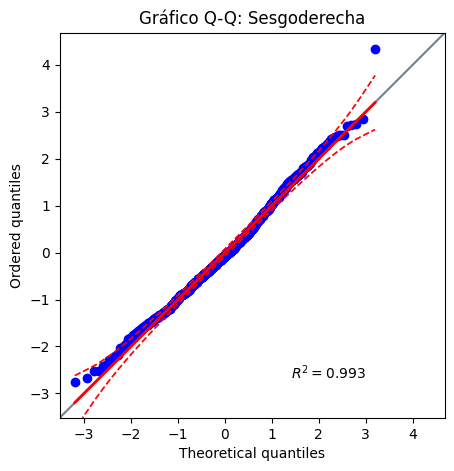

📊 Prueba estadísticas para: sesgo_derecha
  Kolmogorov-Smirnov - Estadística (D) = 0.3167, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)

  Shapiro-Wilk    -    Estadística (W) = 0.9935, p = 0.0002412940 ❌ Rechazar H₀ (p<0.05)



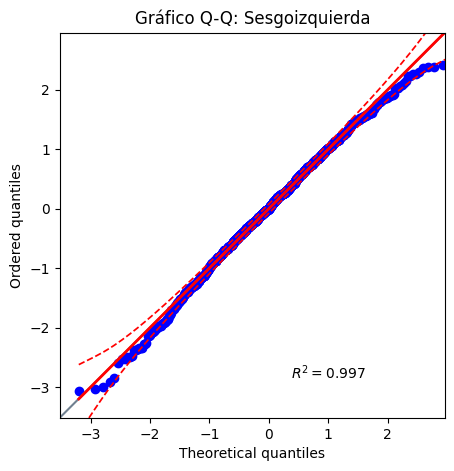

📊 Prueba estadísticas para: sesgo_izquierda
  Kolmogorov-Smirnov - Estadística (D) = 0.3094, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)

  Shapiro-Wilk    -    Estadística (W) = 0.9962, p = 0.0158835142 ❌ Rechazar H₀ (p<0.05)



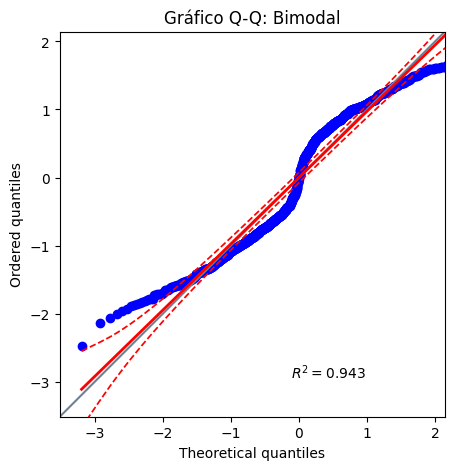

📊 Prueba estadísticas para: bimodal
  Kolmogorov-Smirnov - Estadística (D) = 0.3071, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)

  Shapiro-Wilk    -    Estadística (W) = 0.9418, p = 0.0000000000 ❌ Rechazar H₀ (p<0.05)



In [7]:
# Iterar por cada columna, obtener gráfico Q-Q e imprimir en pantalla resultados pruebas 
# KS y Shapiro-Wilk

for column in df.columns:
    # Gráfico
    fig, ax = plt.subplots(figsize=(5, 5))
    pg.qqplot(df[column], dist='norm', confidence=.95, ax=ax)
    ax.set_title(f"Gráfico Q-Q: {column.replace('_', '').capitalize()}")
    plt.show()

    # Pruebas
    D, p_ks = kstest(df[column], 'norm', args=(0, 1)) # args=(0,1): distribución normal estandarizada
    W, p_shapiro = shapiro(df[column])

    # Imprimir resultado
    print(f"📊 Prueba estadísticas para: {column}")
    print(f"  Kolmogorov-Smirnov - Estadística (D) = {D:.4f}, p = {p_ks:.10f} {'❌ Rechazar H₀ (p<0.05)' if p_ks < 0.05 else '✅ No se rechaza H₀ (p>=0.05)'}\n")
    print(f"  Shapiro-Wilk    -    Estadística (W) = {W:.4f}, p = {p_shapiro:.10f} {'❌ Rechazar H₀ (p<0.05)' if p_shapiro < 0.05 else '✅ No se rechaza H₀ (p>=0.05)'}\n")